<a href="https://colab.research.google.com/github/stephentangzizhong/Neuroinformatics-Workshop-Code/blob/main/10_Past_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NEUR0019 EXAM 2023 / 24

In this assessment, we will simulate some responses to a sequence of sensory stimuli, and test the null hypothesis that neurons do not respond to the stimulus using a pseudosession test.

**Instructions**


*   Do not use AI tools for this assessment
*   Go through the notebook top to bottom. Run all cells that contain code
*   Answer all QUESTIONs in the cells below
*   Write and execute code where requested



In [ ]:
# Import the libraries we will need
import numpy as np
import matplotlib.pyplot as plt

In the simulation, 100 stimuli are delivered with an interstimulus interval uniformly distributed between 1 and 2 seconds. The interstimulus intervals are all independent of each other.  Here is the code that generates it:


In [ ]:
def generate_stimuli(t1, t2, n):
  """
  Generate stimlus times with uniformly-distributed random independent
  interstimulus intervals.

  Parameters:
    t1 (float): shortest possible interstimulus interval
    t2 (float): longest possible interstimulus interval
    n (int): number of stimuli

  Returns:
    stimulus_times (float): times of all stimuli


  """
  interstimulus_intervals = np.random.uniform(t1,t2,n)
  stimulus_times = np.cumsum(interstimulus_intervals)
  return stimulus_times


**Q1:** What is the probability distribution of the first stimulus time?

It's a uniform distribution between 1 and 2 seconds.


**Q2:** Are the **stimulus times** distributed according to a Poisson process? Justify your answer. (Reminder: the definition of a Poisson process was given in [this lecture](https://drive.google.com/file/d/1hFg6F79iodNyaPuKxqNTf8cVlbY9X_z-/view))

(The question is asking the stimulus times, not intervals.)
No, because in a Poisson Process, the stimuli are independent from each other. But here, in contrast, stimulus intervals cannot take values outside of 1-2 seconds, which makes the stimuli not independent from each other.



Now let's generate some stimuli and plot them

Text(0, 0.5, 'stimulus time (s)')

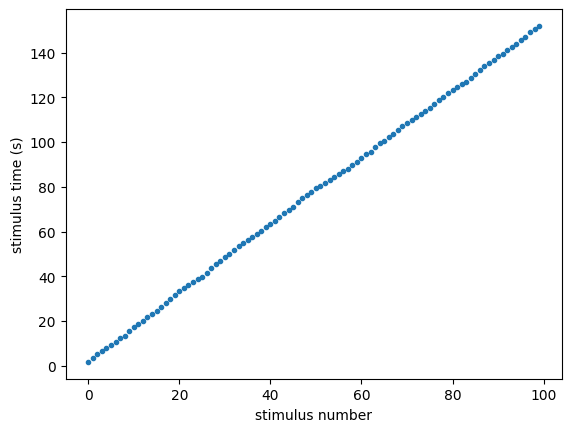

In [ ]:
stimulus_times = generate_stimuli(1,2,100)
plt.plot(stimulus_times, '.')
plt.xlabel('stimulus number')
plt.ylabel('stimulus time (s)')

**Q3**: Why does it look like a slightly wiggly straight line?  What slope does the line have? (Give a unit.)

A perfect straight line would require all intervals to be exactly the same. But here the stimulus intervals come from a uniform distribution. They have a mean of 1.5s, but they are not exactly 1.5.

The slope is 1.5 seconds per stimulus.

Now let's simulate the activity of a neuron.  It has a background firing rate independent of stimuli, and responds to each stimulus with a spike with a fixed probability, which it fires at a random time.  

In [ ]:
def generate_spikes(background_rate, response_prob, response_delay,
                    response_delay_sd, stimulus_times):
  """
  Generate spikes of a neuron that has background firings and responds to
  each stimuli with one spike (fixed probability, random delays).

  Parameters:
    background_rate (float):
    response_prob (float):
    response_delay (float):
    response_delay_sd (float):
    stimulus_times (float array):

  Returns:
    spike_times (float array): times of all spikes

  """

  # set the window for spikes
  max_time = stimulus_times.max() + 1.0

  # generate background firings
  background_spikes = np.random.uniform(0,max_time,
                              (max_time*background_rate).astype(int))

  # create a empty list for reponse to stimuli
  response_spikes = list()

  # generate response to stimuli
  # iterate through each stimuli
  for s in stimulus_times:
      # set the probability of response
      if np.random.rand()<response_prob:
        # generate time of each response spike
        response_spikes.append(s + np.random.normal(response_delay,
                                                response_delay_sd))

  # combine background firings with response to stimuli
  spike_times = np.concatenate((background_spikes, response_spikes))

  # sort the firings by time
  spike_times.sort()


  return spike_times


**Q4**: Add comments to the generate_spikes code. Include a docstring similar to that in generate_simuli, and explain what the lines do

In [ ]:
# See answer in the cell above.

**Q5**: Are the background spikes distributed according to a Poisson process? Are they approximately Poisson?

No because the 'np.random.uniform' function draws samples from a uniform distribution. The number of spikes is constant (i.e. equal to the bacground firing rate multiplied by the duration of all stimuli, plus 1 s). For a Poisson process, the total number of spikes would be Poisson distributed. However the spike times are uniformly random which is approximately like a Poisson process (if you take an interval from the window, the counts would look like Poisson because it's still random).


**Uniformly Random**: Every point in time has an equal probability of hosting a spike. About location of the spikes.

**Poisson Process**: The number of spikes in any interval follows a Poisson distribution. About count of the spikes.

([], [])

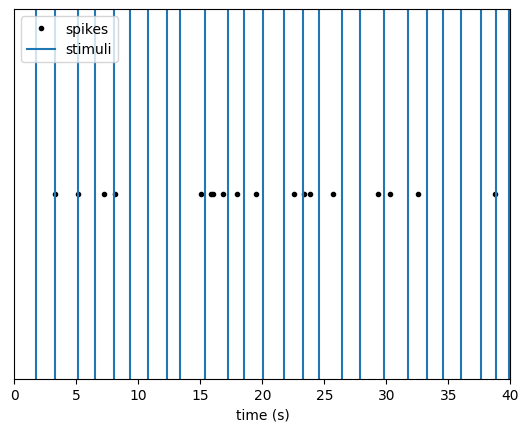

In [ ]:
# Generate some spikes and a raster plot
spike_times = generate_spikes(.3,.1,.1,.05,stimulus_times)

plt.plot(spike_times, np.ones_like(spike_times), 'k.')
for s in stimulus_times:
  plt.axvline(s)
plt.xlim([0,40])
plt.legend(('spikes', 'stimuli'))
plt.xlabel('time (s)')
plt.yticks([])

Now we will test the null hypothesis that the firing of this neuron is independent of the stimuli.  To do so we generate 999 pseudosessions corresponding to different possible stimulus times that could have been shown.  We define a test statistic as the number of spikes occurring within 200 ms of a stimulus, and compare to the null distribution

In [ ]:
def test_stat(stimulus_times, spike_times, time_win):

  """
  Compute test statistic for one trial, counting the number of
  spikes occuring within 200 ms of a stimulus.

  Parameters:
  stimulus_times: time of each stimulus
  spike_times (float): time of each spike
  time_win (float): time window after each stimulus

  Returns:
  n_spikes (int): number of spikes occuring within 200 ms of a stimulus

  """

  n_spikes = 0

  # iterate through each stimulus
  for s in stimulus_times:
    # compute time difference between all spikes and this stimulus
    t_diff = spike_times-s
    # count the number of spikes with time difference less than 200 ms, and add to total
    n_spikes += np.sum((t_diff>=0) & (t_diff<time_win))

  return n_spikes

p value 0.008000


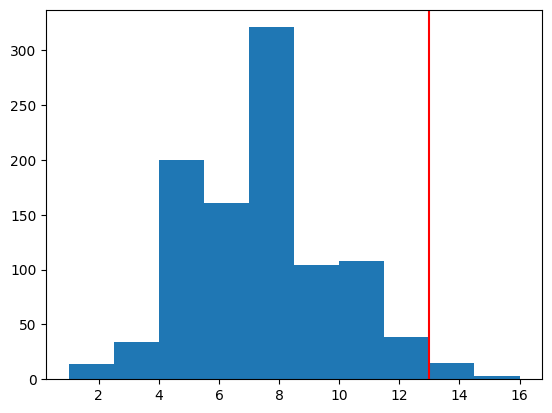

In [ ]:
# compute the actual statistic
real_stat = test_stat(stimulus_times, spike_times, 0.2)

# create null ensemble
# create an empty distribution with 999 pseudotrials
n_null = 999
null_distribution = np.zeros(n_null)
# iterate through every pseudotrial in the distribution
for i in range(n_null):
  # randomly regenerate stimuli
  pseudo_stimuli = generate_stimuli(1,2,100)
  # compute test statistic for each pseudotrial
  null_distribution[i]=test_stat(pseudo_stimuli, spike_times,0.2)

# plot a histogram for the null distribution
plt.hist(null_distribution)
# draw a line for the actual test statistic
plt.axvline(real_stat, color='r')

# compute p-value for the significance test
print('p value %f'%((1+sum(real_stat<null_distribution))/(1+n_null)))

**Q6:** When applying the pseudosession test in an actual experiment like this, why do we randomly regenerate the stimuli but not the spikes?  
Because we regenerate what was randomly generated. In an actual experiment we can't regenerate the spikes because they were measured experimentally - we do not have access to information about how they were generated.

**Q7:** Add comments to the function test_stat and to the cell below that does the pseudosession test


**Q8:** Why can't the p-value be 0?  
Because the actual test statistic is part of the distribution in the significance test. A p-value of zero implies that the probability of seeing the data we actually saw was zero.

**Q9:** Redo this analysis for a simulated cell that has the same background rate but does not respond to the stimulus

p value 0.775000


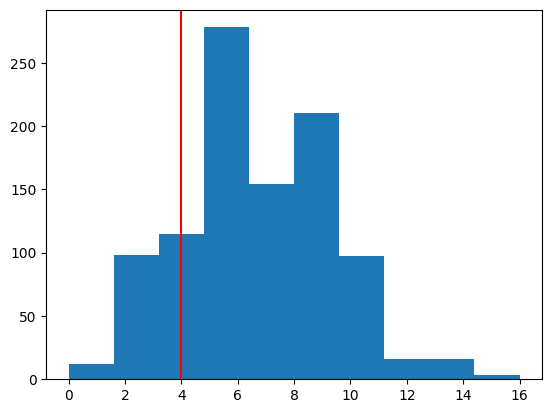

In [ ]:
max_time = stimulus_times.max() + 1.0

background_spikes = np.random.uniform(0,max_time,
                            (max_time*.3).astype(int))

background_spikes.sort()

real_stat = test_stat(stimulus_times, background_spikes, 0.2)

n_null = 999
null_distribution = np.zeros(n_null)

for i in range(n_null):
  pseudo_stimuli = generate_stimuli(1,2,100)
  null_distribution[i]=test_stat(pseudo_stimuli, spike_times,0.2)

plt.hist(null_distribution)
plt.axvline(real_stat, color='r')

print('p value %f'%((1+sum(real_stat<null_distribution))/(1+n_null)))


p value 0.759000


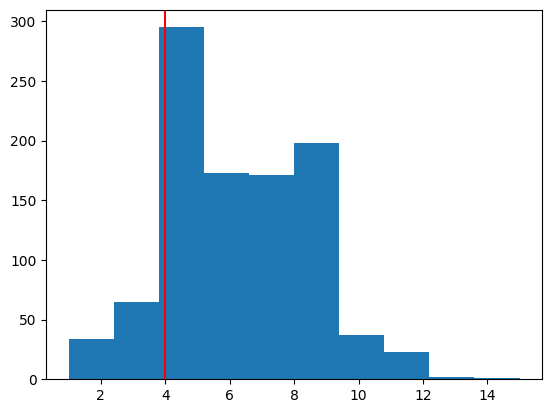

In [ ]:
# MODEL ANSWER

spike_times0 = generate_spikes(.3,0,.1,.05,stimulus_times)  # Set the response probability input to zero

real_stat = test_stat(stimulus_times, spike_times0, 0.2)

n_null = 999
null_distribution = np.zeros(n_null)
for i in range(n_null):

  pseudo_stimuli = generate_stimuli(1,2,100)

  null_distribution[i]=test_stat(pseudo_stimuli, spike_times0,0.2)

plt.hist(null_distribution)
plt.axvline(real_stat, color='r')

print('p value %f'%((1+sum(real_stat<null_distribution))/(1+n_null)))